# Polynomial Regression — Statistics

**Goal.** Make the bias–variance picture from `01_intuition.ipynb` §3 mathematically precise: derive the **bias–variance decomposition** of expected prediction error, watch how each term moves with the polynomial degree d, and turn that into a concrete model-selection rule (k-fold cross-validation). Also confront one polynomial-specific pathology — the **Runge phenomenon** — that shows interpolating with high-degree polynomials on equispaced nodes can produce *worse* fits as d grows, even with no noise.

**Role of this notebook.** Estimator theory: math first, with minimal Monte Carlo si$\mu$lations used only to *verify* a theorem or visualise the trade-off. All Gauss–Markov ma$\chi$nery from `01_linear_regression/04_statistics.ipynb` carries over unchanged; this notebook focuses on what is *new* about polynomial regression — the **degree** as a tuning knob.

**Prerequisites.** `01_linear_regression/04_statistics.ipynb` (sampling identity, OLS variance for$\mu$la); `02_mathematics.ipynb` of this folder (feature map $\Phi_d$, OLS-on-$\Phi$).

**Stage map.** `01_intuition` → `02_mathematics` → `03_optimization` → **`04_statistics`** → `05_hands_on_programming`.

**Six questions.**

1. What exactly is the "prediction error" we want to minimise?
2. How does that error split into bias^2, variance, and noise?
3. How does each term move as we increase the degree d?
4. How do we *choose* d without peeking at the test set?
5. Can high-degree polynomials fail catastrophically even without noise?
6. What information criteria (AIC, BIC) say about model size.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import random

import numpy as np
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

plt.rcParams["figure.dpi"] = 90

## 1. Setup: random data, fixed query point

Let f: $\mathbb{R}$ → $\mathbb{R}$ be the unknown true regression function. The training set is a random draw

> D = {($x_i$, $y_i$)}_{i=1}^n,    $y_i$ = f($x_i$) + $\varepsilon$_i,    $\varepsilon$_i i.i.d.  $\mathcal{N}$(0, $\sigma^2$).

We fit a polynomial of degree d to D and obtain a (random) function f̂_D : $\mathbb{R}$ → $\mathbb{R}$. We are interested in how well f̂_D predicts at a **fixed** query point x_0, *across* repeated draws of D.

**Expected prediction error at x_0.** For a fresh noise term $\varepsilon$_0 ~ $\mathcal{N}$(0, $\sigma^2$) independent of D:

> EPE(x_0)  :=  𝔼_{D, $\varepsilon$_0} [ ( y_0 $-$ f̂_D(x_0) )^2 ],   where  y_0 = f(x_0) + $\varepsilon$_0.   (1.1)

The expectation is over both the random training set D and the random target y_0 at x_0.

## 2. The bias–variance decomposition

> **Theorem 2.1 (bias–variance decomposition).** For any estimator f̂_D and any x_0,
>
> EPE(x_0)  =  Bias(x_0)^2  +  Var(x_0)  +  $\sigma^2$,
>
> where
>
> Bias(x_0)  :=  𝔼_D[ f̂_D(x_0) ]  $-$  f(x_0),    Var(x_0)  :=  Var_D( f̂_D(x_0) ).

**Proof.** Let g_0 := 𝔼_D[ f̂_D(x_0) ] (the *average prediction* at x_0 across training sets). Then y_0 $-$ f̂_D(x_0) = (y_0 $-$ f(x_0)) + (f(x_0) $-$ g_0) + (g_0 $-$ f̂_D(x_0)) = $\varepsilon$_0 + ($-$Bias(x_0)) + (g_0 $-$ f̂_D(x_0)). Square and take expectations. All three cross terms vanish: $\varepsilon$_0 is independent of D and has mean 0; (g_0 $-$ f̂_D(x_0)) has mean 0 by definition of g_0; and Bias(x_0) is deterministic. What remains is

```
EPE(x_0)  =  𝔼[$\varepsilon$_0^2]  +  Bias(x_0)^2  +  𝔼_D[ (g_0 $-$ f̂_D(x_0))^2 ]
          =  $\sigma^2$       +  Bias(x_0)^2  +  Var(x_0).   ∎
```

**Reading.** The three terms have very different meanings.

| Term | Meaning | Knob it depends on |
|---|---|---|
| **$\sigma^2$** | irreducible noise, the floor below which no estimator can go | the data-generating process — nothing the modeller can do |
| **Bias(x_0)^2** | systematic error: the *average* prediction at x_0 is wrong | model class. Larger d ⇒ richer class ⇒ smaller bias |
| **Var(x_0)** | how $\mu$ch the prediction at x_0 jiggles across training sets | model complexity vs. data size. Larger d ⇒ more parameters ⇒ more variance |

Increasing d trades bias for variance. Decreasing d does the opposite. The U-shaped test-error curve from `01_intuition.ipynb` §3 is *exactly* the picture of Bias^2 + Var as a function of d.

### 2.1 Monte Carlo bias–variance estimation

Pick a true f, a query point x_0, and replicate the training set M times. For each replication, fit a polynomial of degree d and record f̂_D(x_0). Average over replications to estimate Bias and Var directly. Repeat for a sweep of d, then plot bias^2, variance, and their sum.

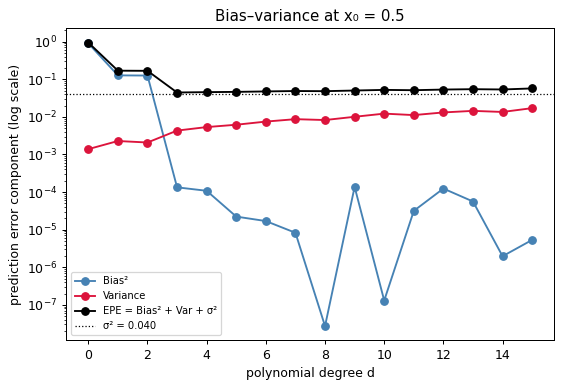

empirical best degree at x₀: d* = 3


In [2]:
def true_f(t):
    return np.sin(2.5 * t)

sigma   = 0.2          # noise standard deviation
n       = 30           # training-set size per replicate
x0      = 0.5          # query point
x_grid  = np.linspace(-1, 1, n)
M       = 400          # number of replicates per degree
degrees = np.arange(0, 16)

bias2 = np.empty(len(degrees))
var_  = np.empty(len(degrees))

rng_mc = np.random.default_rng(SEED)
for di, d in enumerate(degrees):
    preds = np.empty(M)
    for m in range(M):
        y = true_f(x_grid) + rng_mc.normal(0, sigma, size=n)
        coefs = np.polyfit(x_grid, y, d)            # OLS via the monomial Vandermonde
        preds[m] = np.polyval(coefs, x0)
    bias2[di] = (preds.mean() - true_f(x0)) ** 2
    var_[di]  = preds.var()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(degrees, bias2,                "o-", color="steelblue", label="Bias²")
ax.plot(degrees, var_,                 "o-", color="crimson",   label="Variance")
ax.plot(degrees, bias2 + var_ + sigma**2, "o-", color="black",  label="EPE = Bias² + Var + σ²")
ax.axhline(sigma**2, color="black", ls=":", lw=1, label=f"σ² = {sigma**2:.3f}")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree d")
ax.set_ylabel("prediction error component (log scale)")
ax.set_title(f"Bias–variance at x₀ = {x0}")
ax.legend(fontsize=8)
plt.show()

d_star = degrees[np.argmin(bias2 + var_ + sigma**2)]
print(f"empirical best degree at x₀: d* = {d_star}")

**Reading.**

- Bias^2 drops sharply as d grows from 0 (predict the mean) to a value where the polynomial can match the sine wave — and then plateaus at near-zero.
- Variance is small at low d, then climbs roughly like d (each new parameter brings in new sample-to-sample noise).
- The total EPE is the sum + $\sigma^2$. It bottoms out at d $\approx$ 5–7 for this f — beyond which the variance dominates.

## 3. Choosing d without a separate test set: k-fold cross-validation

In practice we cannot run a Monte Carlo si$\mu$lation — we have one fixed dataset. The standard fix is **k-fold cross-validation**.

### 3.1 Algorithm (k-fold CV)

```
ALGORITHM:  k-fold cross-validation for model selection

Input:   dataset D = {($x_i$, $y_i$)}_{i=1}^n; candidate degrees d_1, ..., d_M; folds k.
Output:  the d* minimising estimated test error.

1.  Partition D into k disjoint folds  D_1, ..., D_k  of roughly equal size.
2.  for each candidate degree d:
3.      for each fold j = 1, ..., k:
4.          fit  f̂_{(j)}  using all data EXCEPT D_j
5.          err_j(d)  $\leftarrow$  (1 / |D_j|) $\cdot$ $\sum$_{(x, y) $\in$ D_j} ( y $-$ f̂_{(j)}(x) )^2
6.      CV(d)  $\leftarrow$  (1/k) $\cdot$ $\sum$_j err_j(d)
7.  return  d*  =  argmin_d  CV(d).
```

### 3.2 Why this works

Each fold acts as a small held-out test set. Because the model that produces the prediction for fold j was trained *without* fold j, the resulting MSE is an (almost-)unbiased estimate of expected prediction error. Averaging over k folds reduces variance compared to a single train/test split.

Common choices:

- **k = 5 or 10.** A good default. Each model is trained on (k $-$ 1)/k of the data — close enough to the full dataset that the bias of CV is small.
- **k = n (leave-one-out, LOO-CV).** Lowest bias, highest variance, most expensive. For *linear* estimators (including OLS on $\Phi_d$), there is a closed-form shortcut using the hat matrix: LOO-MSE = (1/n) $\cdot$ $\sum$_i ( ($y_i$ $-$ $\hat{y}$_i) / (1 $-$ H_{ii}) )^2 — no n separate fits needed.

### 3.3 Demo: k-fold CV picks roughly the same d* as the Monte Carlo oracle

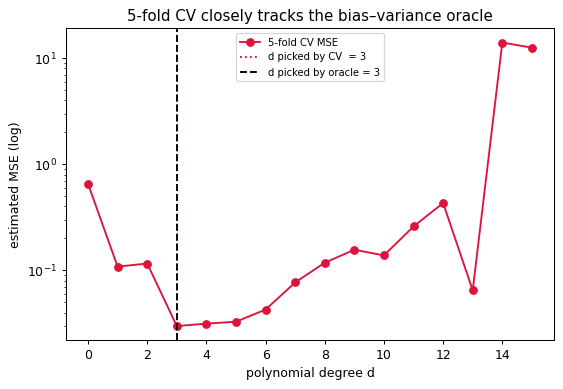

In [3]:
# A single training set; no peeking at the true f for model selection.
x_data = np.linspace(-1, 1, n)
y_data = true_f(x_data) + rng.normal(0, sigma, size=n)

k = 5
fold_id = rng.permutation(n) % k

cv_errors = []
for d in degrees:
    fold_mse = []
    for j in range(k):
        train_mask = (fold_id != j)
        test_mask  = (fold_id == j)
        coefs = np.polyfit(x_data[train_mask], y_data[train_mask], d)
        preds = np.polyval(coefs, x_data[test_mask])
        fold_mse.append(np.mean((y_data[test_mask] - preds) ** 2))
    cv_errors.append(np.mean(fold_mse))
cv_errors = np.array(cv_errors)

d_cv  = degrees[np.argmin(cv_errors)]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(degrees, cv_errors, "o-", color="crimson", label="5-fold CV MSE")
ax.axvline(d_cv,   color="crimson", ls=":", label=f"d picked by CV  = {d_cv}")
ax.axvline(d_star, color="black",   ls="--", label=f"d picked by oracle = {d_star}")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree d")
ax.set_ylabel("estimated MSE (log)")
ax.set_title("5-fold CV closely tracks the bias–variance oracle")
ax.legend(fontsize=8)
plt.show()

## 4. The Runge phenomenon — interpolation is not regression

All the variance issues above were caused by **noise** in y. There is also a *deterministic* failure mode unique to polynomial fitting on equispaced nodes: even with zero noise, high-degree polynomial interpolation can blow up near the edges of the interval. This is the **Runge phenomenon** (Runge 1901).

Try to interpolate the simple function f(x) = 1 / (1 + 25 x^2) on n + 1 equispaced nodes in [$-$1, 1] with the unique polynomial of degree n that passes through all of them.

Theorem (Runge): as n → $\infty$, the interpolant **diverges** uniformly on the interval; the error near x = $\pm$1 grows arbitrarily large despite each node being matched exactly.

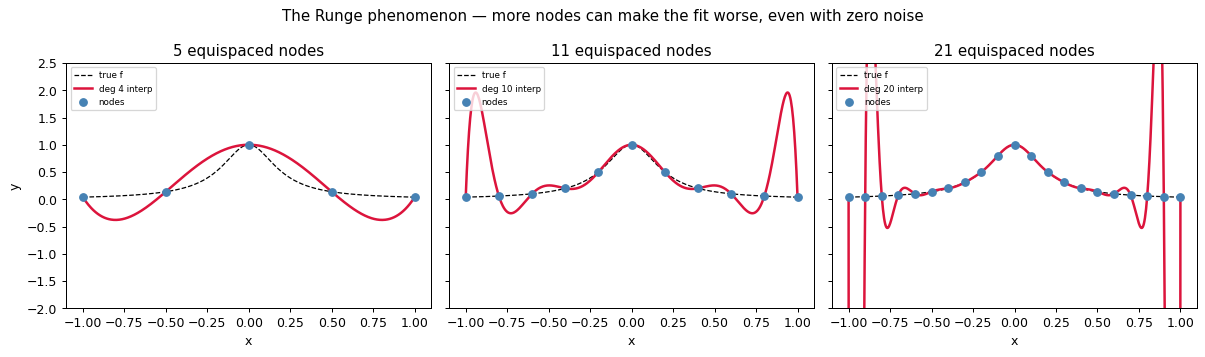

In [4]:
def runge(t):
    return 1.0 / (1.0 + 25.0 * t**2)

xs = np.linspace(-1, 1, 600)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4), sharey=True)
for ax, n_nodes in zip(axes, [5, 11, 21]):
    x_nodes = np.linspace(-1, 1, n_nodes)
    y_nodes = runge(x_nodes)
    coefs   = np.polyfit(x_nodes, y_nodes, n_nodes - 1)   # interpolating polynomial
    ax.plot(xs, runge(xs), color="black", ls="--", lw=1, label="true f")
    ax.plot(xs, np.polyval(coefs, xs), color="crimson", lw=2, label=f"deg {n_nodes - 1} interp")
    ax.scatter(x_nodes, y_nodes, color="steelblue", zorder=3, label="nodes")
    ax.set_ylim(-2, 2.5)
    ax.set_xlabel("x")
    ax.set_title(f"{n_nodes} equispaced nodes")
    ax.legend(fontsize=7, loc="upper left")
axes[0].set_ylabel("y")
plt.suptitle("The Runge phenomenon — more nodes can make the fit worse, even with zero noise")
plt.tight_layout()
plt.show()

**Reading.** With 5 nodes the interpolant follows the true function. With 21 equispaced nodes the polynomial oscillates wildly between the rightmost data points — *despite* hitting every node exactly. The lesson: regression with high-degree monomials on equispaced data is **dangerous**, independent of noise. The classical remedies are:

- Use **Chebyshev nodes** (zeros of T_{n+1}) — these cluster near the endpoints, where equispaced grids leave gaps. Interpolation at Chebyshev nodes converges for all analytic functions.
- Use **regularisation** (Ridge / Lasso — next two algorithm folders) to shrink the coefficients that drive the oscillations.
- Use **piecewise polynomials** (splines) instead of one global polynomial.

In supervised learning the practical version of this lesson: **never** crank d up to n $-$ 1 "because you can". Always select d via CV.

## 5. Information criteria (AIC, BIC) — penalising model size

A cheaper alternative to cross-validation: penalise large models analytically. Two textbook penalties on the maximised log-likelihood ℓ̂ for a model with p parameters:

> **AIC**  :=  $-$2 ℓ̂  +  2 p   (Akaike 1973).
>
> **BIC**  :=  $-$2 ℓ̂  +  p $\cdot$ log n   (Schwarz 1978).

For OLS with Gaussian noise (`01_linear_regression/02_mathematics.ipynb` Theorem 2.2), the maximised log-likelihood reduces — up to constants — to $-$(n/2) $\cdot$ log(RSS / n). Plugging in and dropping additive constants that do not depend on the model:

> AIC_OLS  =  n $\cdot$ log(RSS / n)  +  2 p,                                            (5.1)
>
> BIC_OLS  =  n $\cdot$ log(RSS / n)  +  p $\cdot$ log n.                                       (5.2)

Pick the model with the smallest AIC or BIC.

**Trade-offs.**

- AIC tends to pick *larger* models than BIC because its penalty (2 p) grows more slowly than BIC's (p $\cdot$ log n).
- BIC is **consistent** for model selection: as n → $\infty$, BIC asymptotically picks the true model (if it is in the candidate set). AIC is not consistent but is asymptotically efficient for prediction.
- Both are *vastly* cheaper than k-fold CV — one fit per candidate model — but rely on the Gaussian-noise assumption (A5) to be valid.

When in doubt, run both AIC/BIC and a 5-fold CV. If they agree, ship; if they disagree, the bias–variance trade-off in your particular problem is delicate enough that CV (which uses no distributional assumption) wins.

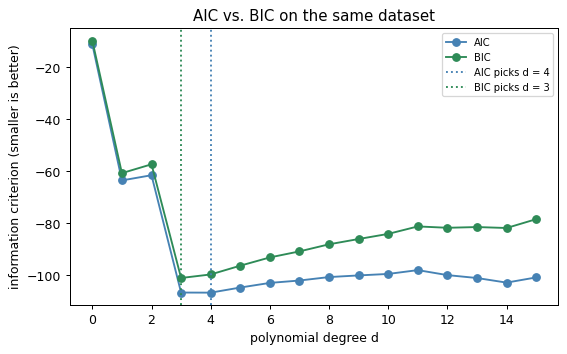

In [5]:
aics, bics = [], []
for d in degrees:
    coefs = np.polyfit(x_data, y_data, d)
    rss   = float(np.sum((y_data - np.polyval(coefs, x_data)) ** 2))
    p     = d + 1
    base  = n * np.log(rss / n)
    aics.append(base + 2 * p)
    bics.append(base + p * np.log(n))
aics, bics = np.array(aics), np.array(bics)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(degrees, aics, "o-", color="steelblue", label="AIC")
ax.plot(degrees, bics, "o-", color="seagreen",  label="BIC")
ax.axvline(degrees[np.argmin(aics)], color="steelblue", ls=":", label=f"AIC picks d = {degrees[np.argmin(aics)]}")
ax.axvline(degrees[np.argmin(bics)], color="seagreen",  ls=":", label=f"BIC picks d = {degrees[np.argmin(bics)]}")
ax.set_xlabel("polynomial degree d")
ax.set_ylabel("information criterion (smaller is better)")
ax.set_title("AIC vs. BIC on the same dataset")
ax.legend(fontsize=8)
plt.show()

## Takeaway

- **Bias–variance (Theorem 2.1).**   EPE = Bias^2 + Variance + $\sigma^2$. Increasing d shrinks bias and grows variance; the test-error mini$\mu$m is where the two cross.
- **Trade-off is real.**   The Monte Carlo plot (§2.1) shows the U-shape numerically. The mini$\mu$m at d\* depends on f, $\sigma^2$, and n.
- **k-fold CV.**   Estimates EPE without a separate test set; tracks the Monte Carlo oracle closely with k = 5 or 10. For OLS specifically, LOO-CV has a closed form via the hat matrix that costs *one* fit.
- **Runge phenomenon.**   High-degree polynomial fitting on equispaced nodes can diverge even with zero noise. Cure: Chebyshev nodes, regularisation, or piecewise polynomials.
- **AIC / BIC.**   Cheaper alternatives to CV. AIC $\approx$ MSE + 2 p; BIC = MSE + p log n. BIC is more conservative and is asymptotically consistent.

Next: `05_hands_on_programming.ipynb` — code up `PolynomialFeatures` from scratch, plug into the `LinearRegressionOLS` class from the previous folder, run CV to pick d, and cross-check against `sklearn.preprocessing.PolynomialFeatures` + `sklearn.linear_model.LinearRegression`.